### Contextualização

#### Introdução

Este desafio utiliza o dataset [Chest X-Ray Images (Pneumonia) - Kaggle](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) para estudar um problema de **classificação supervisionada de imagens médicas**. O objetivo é classificar radiografias de tórax em duas classes: **NORMAL**, quando não há sinais de pneumonia, e **PNEUMONIA**, quando a imagem apresenta indícios da doença.

O problema é relevante para a área de Reconhecimento de Padrões porque envolve a identificação de características visuais em imagens, como textura, contraste e regiões de opacidade pulmonar. Como os dados são imagens médicas, o processo exige etapas de pré-processamento, análise exploratória e avaliação do desempenho dos modelos.

O dataset é composto por radiografias torácicas pediátricas em formato JPEG, organizadas nos subconjuntos **train**, **val** e **test**, cada um contendo as classes **NORMAL** e **PNEUMONIA**. As imagens são provenientes de pacientes entre 1 e 5 anos de idade atendidos no Guangzhou Women and Children’s Medical Center, na China. Antes da disponibilização, as imagens passaram por um processo de controle de qualidade, com remoção de exames de baixa qualidade ou ilegíveis.

#### Exploração Inicial

A análise inicial dos dados mostra que o conjunto está dividido em três partes: treinamento, validação e teste. A distribuição das imagens por classe está da seguinte forma:

| Subconjunto | NORMAL | PNEUMONIA | Total |
| ----------- | -----: | --------: | ----: |
| Treino      |  1.342 |     3.876 | 5.218 |
| Validação   |      9 |         9 |    18 |
| Teste       |    235 |       391 |   626 |

Observa-se que o conjunto de treinamento é desbalanceado, com uma quantidade maior de imagens da classe **PNEUMONIA**. Esse desbalanceamento pode influenciar o treinamento dos modelos, tornando necessário o uso de métricas além da acurácia, como precisão, recall e F1-score.


In [21]:
# imports

import os
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision.models import MobileNet_V2_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Device: cuda
GPU: NVIDIA GeForce 940MX


In [22]:
# settings

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
SPLIT_NAMES = ["train", "val", "test"]

MAX_EPOCHS = 20
PATIENCE = 4
LEARNING_RATE = 0.01
BATCH_SIZE = 32
NUM_WORKERS = 2
FINAL_THRESHOLD = 0.5

SPLIT_TRAIN = 0.70
SPLIT_VAL = 0.15
SPLIT_TEST = 0.15



IMG_EXTENSIONS = ".jpeg"

BEST_MODEL_PATH = f"best_mobilenetv2_asis.pth"
RESULTS_CSV_PATH = f"mobilenetv2_results_asis.csv"
CONFUSION_MATRIX_PATH = f"mobilenetv2_confusion_matrix_asis.png"

ORIGINAL_DATA_ROOT = Path("/home/wagner/Documents/MestradoIfes/datasets/chest_xray")
BALANCED_DATA_ROOT = Path("/home/wagner/Documents/MestradoIfes/datasets/balanced_chest_xray")

### Preparação

Na etapa de preparação dos dados, serão realizados dois experimentos com o objetivo de comparar o desempenho dos modelos em diferentes cenários de distribuição das classes.

No primeiro experimento, será utilizado o **dataset original**, mantendo a estrutura inicial dos dados e o desbalanceamento entre as classes **NORMAL** e **PNEUMONIA**. Essa abordagem permite avaliar como o modelo se comporta quando treinado com a distribuição original das imagens, na qual há uma quantidade maior de exemplos da classe **PNEUMONIA**.

No segundo experimento, será criado um **novo dataset balanceado** utilizando a técnica de **undersampling**. Essa técnica consiste em manter todos os dados da classe com menor frequência e reduzir a quantidade de amostras da classe majoritária. Dessa forma, o conjunto passa a ter uma distribuição mais equilibrada da variável alvo, evitando que o modelo favoreça excessivamente a classe mais frequente durante o treinamento.

Após o balanceamento, o novo dataset será dividido em três subconjuntos:

| Subconjunto | Proporção |
| ----------- | --------: |
| Treinamento |       70% |
| Validação   |       15% |
| Teste       |       15% |

Essa nova divisão será utilizada para treinar, validar e testar os modelos em um cenário com classes equilibradas. Com isso, será possível comparar os resultados obtidos no dataset original desbalanceado com os resultados obtidos no dataset balanceado, analisando o impacto do balanceamento no desempenho dos classificadores.


In [23]:
# faz o balanceamento do dataset original pela técnica de unsersampling, baseado na classe NORMAL que possui menos exemplos
# não precisa executar esse código toda vez, apenas quando quer criar um novo dataset balanceado

import shutil

paths_by_label = {CLASS_NAMES[0]: [], CLASS_NAMES[1]: []}
seen_paths = set()

for split_name in SPLIT_NAMES:
    split_dir = ORIGINAL_DATA_ROOT / split_name

    for folder_name in CLASS_NAMES:
        class_dir = split_dir / folder_name
        if class_dir.exists() and class_dir.is_dir():
            for image_path in class_dir.rglob("*"):
                if image_path.is_file() and image_path.suffix.lower() in IMG_EXTENSIONS:
                    resolved = image_path.resolve()
                    if resolved not in seen_paths:
                        paths_by_label[folder_name].append(image_path)
                        seen_paths.add(resolved)

for class_name in CLASS_NAMES:
    print(f"Original {class_name}: {len(paths_by_label[class_name])}")

min_count = min(len(paths_by_label[CLASS_NAMES[0]]), len(paths_by_label[CLASS_NAMES[1]]))

rng = random.Random(SEED)
selected_by_label = {
    label: rng.sample(paths_by_label[label], min_count)
    for label in CLASS_NAMES
}

if BALANCED_DATA_ROOT.exists():
    shutil.rmtree(BALANCED_DATA_ROOT)

for split_name in SPLIT_NAMES:
    for class_name in CLASS_NAMES:
        (BALANCED_DATA_ROOT / split_name / class_name).mkdir(parents=True, exist_ok=True)

split_pairs = {SPLIT_NAMES[0]: [], SPLIT_NAMES[1]: [], SPLIT_NAMES[2]: []}

for class_name in CLASS_NAMES:
    selected_paths = selected_by_label[class_name]

    train_paths, temp_paths = train_test_split(
        selected_paths,
        train_size=SPLIT_TRAIN,
        random_state=SEED
    )

    val_paths, test_paths = train_test_split(
        temp_paths,
        test_size=0.50,
        random_state=SEED
    )

    split_pairs[SPLIT_NAMES[0]].extend((path, class_name) for path in train_paths)
    split_pairs[SPLIT_NAMES[1]].extend((path, class_name) for path in val_paths)
    split_pairs[SPLIT_NAMES[2]].extend((path, class_name) for path in test_paths)

for split_name, pairs in split_pairs.items():
    for i, (image_path, class_name) in enumerate(pairs):
        dst_name = f"{class_name}_{split_name}_{i}_{image_path.name}"
        shutil.copy2(image_path, BALANCED_DATA_ROOT / split_name / class_name / dst_name)

print("Balanced dataset created successfully in:", BALANCED_DATA_ROOT)

for split_name in ["train", "val", "test"]:
    print("|",split_name.upper())
    total = 0
    for class_name in CLASS_NAMES:
        n = len(list((BALANCED_DATA_ROOT / split_name / class_name).glob("*")))
        total += n
        print("|--",class_name, ":", n)
    print("Total", split_name, ":", total)

Original NORMAL: 1583
Original PNEUMONIA: 4273
Balanced dataset created successfully in: /home/wagner/Documents/MestradoIfes/datasets/balanced_chest_xray
| TRAIN
|-- NORMAL : 1108
|-- PNEUMONIA : 1108
Total train : 2216
| VAL
|-- NORMAL : 237
|-- PNEUMONIA : 237
Total val : 474
| TEST
|-- NORMAL : 238
|-- PNEUMONIA : 238
Total test : 476


In [29]:
# Classe que representa o dataset

class ChestXRayDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        self.classes = CLASS_NAMES

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label = self.samples[index]
        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label
    
# funcoes para montar os datasets de treino, validação e teste
def read_samples_by_folder(data_root, split_name):
    split_dir = Path(data_root) / split_name

    samples = []
    seen_paths = set()

    for label in CLASS_NAMES:
        class_dir = split_dir / label

        for image_path in class_dir.rglob("*"):
            if image_path.is_file() and image_path.suffix.lower() in IMG_EXTENSIONS:
                resolved = image_path.resolve()
                
                if resolved not in seen_paths:
                    samples.append((str(image_path), label))
                    seen_paths.add(resolved)

    return samples

def print_class_counts(name, samples):
    counts = Counter(label for _, label in samples)

    print(f"{name} images:", len(samples))
    print(f"|--NORMAL:", counts[CLASS_NAMES[0]])
    print(f"|--PNEUMONIA:", counts[CLASS_NAMES[1]])

In [30]:
original_train_samples = read_samples_by_folder(ORIGINAL_DATA_ROOT, "train")
original_val_samples = read_samples_by_folder(ORIGINAL_DATA_ROOT, "val")
original_test_samples = read_samples_by_folder(ORIGINAL_DATA_ROOT, "test")

print("split: 70% Train / 15% Validation / 15% Test")
print_class_counts("Train", original_train_samples)
print_class_counts("Validation", original_val_samples)
print_class_counts("Test", original_test_samples)

total_images = len(original_train_samples) + len(original_val_samples) + len(original_test_samples)
print("Total images used:", total_images)

split: 70% Train / 15% Validation / 15% Test
Train images: 5216
|--NORMAL: 1341
|--PNEUMONIA: 3875
Validation images: 16
|--NORMAL: 8
|--PNEUMONIA: 8
Test images: 624
|--NORMAL: 234
|--PNEUMONIA: 390
Total images used: 5856


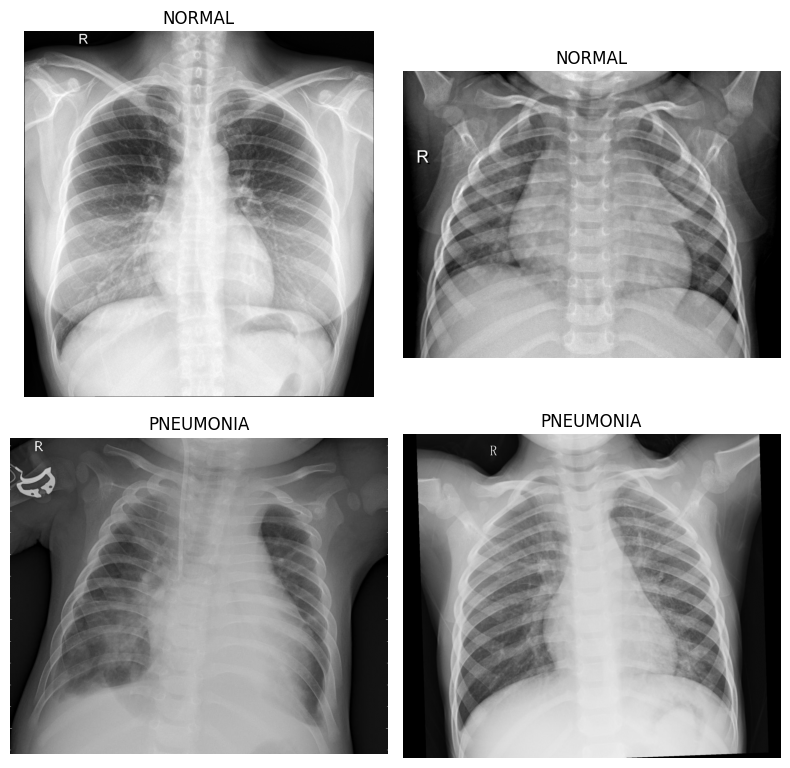

In [35]:
# Cell 7 — Show sample images

def show_sample_images(samples, n_per_class=2):
    fig, axes = plt.subplots(
        len(CLASS_NAMES),
        n_per_class,
        figsize=(4 * n_per_class, 4 * len(CLASS_NAMES))
    )

    for class_name in CLASS_NAMES:
        class_samples = [path for path, y in samples if y == class_name]

        if len(class_samples) == 0:
            continue

        chosen_paths = random.sample(
            class_samples,
            min(n_per_class, len(class_samples))
        )

        for i, image_path in enumerate(chosen_paths):
            image = Image.open(image_path)
            axes[CLASS_NAMES.index(class_name), i].imshow(image, cmap="gray")
            axes[CLASS_NAMES.index(class_name), i].set_title(class_name)
            axes[CLASS_NAMES.index(class_name), i].axis("off")

    plt.tight_layout()
    plt.show()


show_sample_images(original_train_samples, n_per_class=2)

### Aplicação das Técnicas de Aprendizado de Máquina

### Avaliação dos Resultados

### Conclusão